# **Project Tittle**

# Netflix Movie Recommendation System
Capstone Project

**Author:** Aditi Singh  
**Tools Used:** Python, Pandas, NumPy

# **Introduction**


Recommendation systems are widely used in streaming platforms such as Netflix and Amazon Prime.
They analyze user behavior, preferences, and ratings to suggest personalized content.

In this project, we build a movie recommendation system that suggests movies to users based on their ratings and interests.

## Problem Statement

Customer behavior prediction is an essential part of modern businesses.
Streaming platforms collect user activity data such as ratings and viewing patterns.

Using this data, we can build a recommendation engine that suggests movies that match user preferences.

## Objectives

1. Identify the most popular movie genres.
2. Build a recommendation model that suggests movies to users.
3. Analyze which genres receive the highest and lowest ratings.

## Dataset Information

The dataset contains information about users, movies, and ratings.

Columns:

User_ID – Unique ID for each user  
Movie_ID – Unique ID for each movie  
Rating – Rating given by users  
Genre – Category of the movie  
Movie_Name – Name of the movie

# Import Libraries

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install scikit-surprise --prefer-binary

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 re

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
^C


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load DataSet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset= pd.read_csv('/content/drive/MyDrive/Data Set/combined_data_1.txt', header= None, names= ['Cust_Id', 'Rating'], usecols = [0,1])

In [ ]:
dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


# Data Understanding

In [ ]:
dataset.shape

(24058263, 2)

In [ ]:
dataset.tail(5)

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [ ]:
dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_Id  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [ ]:
dataset.describe()

,Rating
count,2.405376e+07
mean,3.599634e+00
std,1.086118e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00


In [ ]:
dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


# Exploratory Data Analysis (EDA)

In the dataset, rows where the Rating column contains NaN values represent Movie IDs. Therefore, we count these NaN entries to determine the total number of movies.

In [ ]:
#get the movie count ( as the NaN values in Rating column will show how many movie are there )
movie_count=dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

4499

The total number of unique customers is calculated by subtracting the movie count from the total unique values in the Customer ID column.

In [ ]:
customer_count=dataset['Cust_Id'].nunique()
customer_count

475257

In [ ]:
customer_count - movie_count

470758

**The dataset contains approximately 4 lakh 70 thousand 758 unique customers.**


In [ ]:
# Calculate the total number of ratings provided by customers for all movies combined
rating_count = dataset['Cust_Id'].count()-movie_count
rating_count

24053764

To determine the number of customers who rated movies with 1-star, 2-star, 3-star, 4-star, and 5-star ratings.

In [ ]:
stars= dataset.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


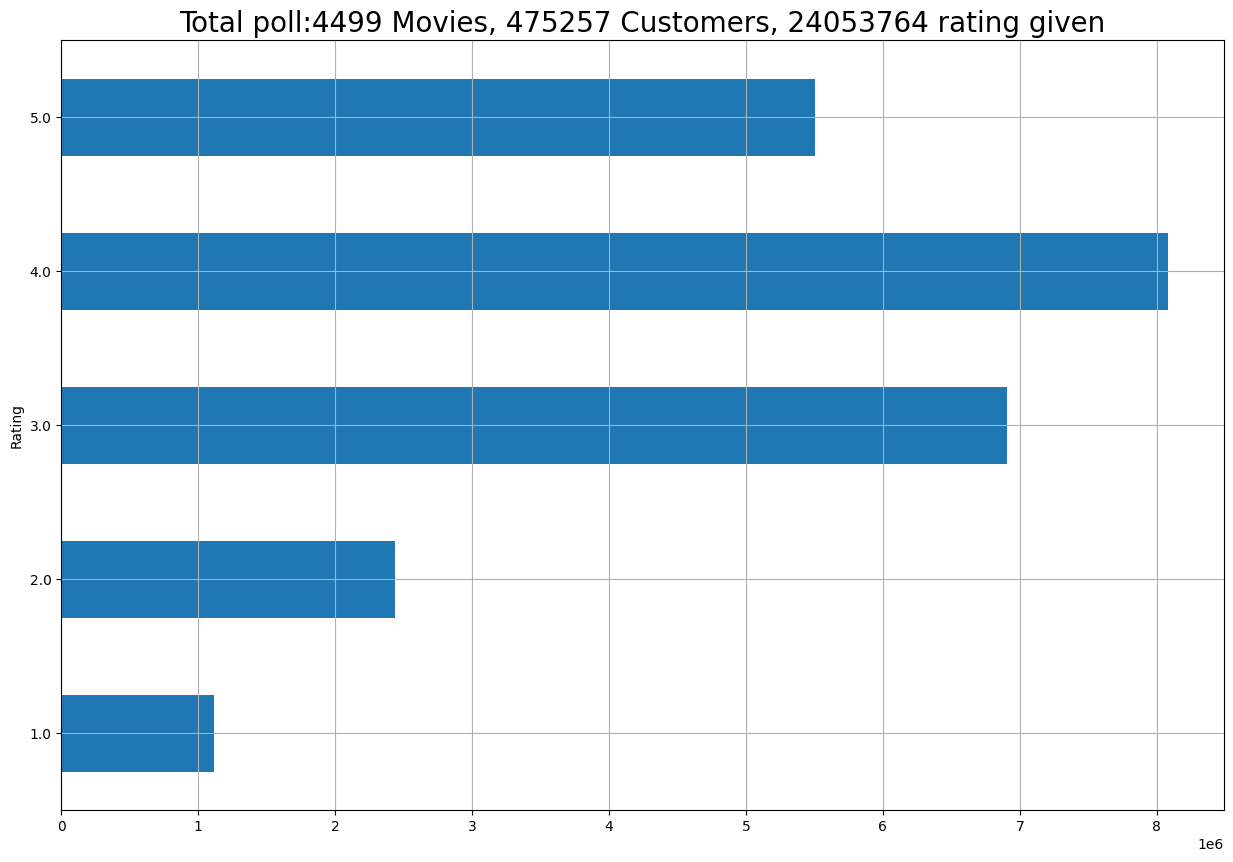

In [ ]:
### Rating Distribution Analysis

ax=stars.plot(kind='barh', legend=False, figsize=(15,10))

plt.title(f'Total poll:{movie_count} Movies, {customer_count} Customers, {rating_count} rating given', fontsize=20)
plt.grid(True)

The bar plot illustrates the distribution of customer ratings for movies. We can observe that 4-star ratings are the most frequent, followed by 3-star and 5-star ratings, while 1-star ratings are the least common.

# Data Cleaning

In [ ]:
# Create a clean DataFrame to determine the total number of Movie IDs
movie_id=None
movie_np =[]
# Iterate over the DataFrame rows
for cust_id in dataset['Cust_Id']:
    if ':' in cust_id:
      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [ ]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
# Add the new column to the DataFrame
dataset['Movie_Id'] = movie_np

In [ ]:
dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
dataset = dataset[dataset['Rating'].notna()]
dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [ ]:
# After removing rows where Movie IDs appeared with NaN ratings (e.g., 1:NaN, 2:NaN),
# the Cust_Id column now contains only valid customer IDs.
# Therefore, we convert the Cust_Id column to integer data type.

dataset["Cust_Id"] = dataset["Cust_Id"].astype(int)

/tmp/ipykernel_641/1108688808.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Cust_Id"] = dataset["Cust_Id"].astype(int)


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


# Pre-filtering:
To improve the quality of the recommendation system, we filter out users who have rated only a small number of movies and movies that have received very few ratings. This helps reduce noise and ensures more reliable recommendations.

In [ ]:
# In this step, we remove users who have rated only a few movies
# and movies that have received very few ratings.
# This helps improve the quality and reliability of the recommendation system.
dataset_movie_summary= dataset.groupby('Movie_Id')['Rating'].agg(["count"])

In [ ]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [ ]:
# Create a benchmark to identify movies that have received a sufficient number of ratings.
# Here we use the 60th percentile of the rating count as the threshold.

movie_benchmark = round(dataset_movie_summary['count'].quantile(0.6), 0)
movie_benchmark

908.0

In [ ]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [ ]:
len(drop_movie_list)

2699

In [ ]:
# movies left
4499-2699

1800

In [ ]:
# Create a summary table to count the number of ratings given by each customer.
# This helps us identify inactive users who have rated only a few movies.

dataset_cust_summary = dataset.groupby('Cust_Id')['Rating'].agg(["count"])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [ ]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [ ]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [ ]:
len(drop_cust_list)

282042

To improve the quality of the recommendation system, we filter out movies with very few ratings and customers who have rated only a small number of movies. This helps reduce noise and ensures more reliable recommendations.


In [ ]:
dataset=dataset[~dataset['Movie_Id'].isin(drop_movie_list)]
dataset=dataset[~dataset['Cust_Id'].isin(drop_cust_list)]
print('After the triming, the shape is: {}'.format(dataset.shape))

After the triming, the shape is: (19695836, 3)


Clean netflix dataset

In [ ]:
dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


# **Build Recommendation Model**

In [ ]:
df_title = pd.read_csv('/content/drive/MyDrive/Data Set/movie_titles (1).csv',encoding='latin',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

In [ ]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
!pip install surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554974 sha256=395542ce23d92bdff442e36900c62d493545b28f89c61e77c31784567b6c7f34
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [ ]:
reader = Reader()

In [ ]:
#we only work with top 2500000 rows for quick runtime
data= Dataset.load_from_df(dataset[['Cust_Id','Movie_Id','Rating']][:2500000], reader)

In [ ]:
model=SVD()

In [ ]:
cross_validate(model, data, measures=['RMSE'], cv=3)  # Trained the model

{'test_rmse': array([0.97253999, 0.97302677, 0.97179336]),
 'fit_time': (42.31267189979553, 42.580138206481934, 42.62617754936218),
 'test_time': (12.65182614326477, 9.151808261871338, 11.64043116569519)}

# **Use model for making Recommendation for a specific user**

In [ ]:
dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [ ]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
# Filter the dataset for the specific user you have selected to make recommnedation to that user
user_ratings = dataset[dataset['Cust_Id'] == 1559566]
user_ratings

,Cust_Id,Rating,Movie_Id
42165,1559566,3.0,18
211169,1559566,4.0,30
262256,1559566,3.0,57
574768,1559566,4.0,171
1062656,1559566,3.0,241
...,...,...,...
23172958,1559566,3.0,4354
23805494,1559566,4.0,4432
23816096,1559566,3.0,4442
23945464,1559566,5.0,4472


In [ ]:
# Find the number of unique movies rated by the user
movies_rated_by_user = user_ratings['Movie_Id'].nunique()

print(f"User 1559566 has rated {movies_rated_by_user} unique movies.")

User 1559566 has rated 132 unique movies.


In [ ]:
copy_data_for_user = df_title.copy()   #making a copy for each individual customer for the recomendation
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
CLEAN_copy_data_for_user = copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user   # Removing the movie les then benchmark for this user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1559566, x).est)
# predict the score (rating) that a user (with user ID 1331154) might give to a list of movies.

/tmp/ipykernel_641/1570203973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1559566, x).est)


In [ ]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.883629
4,5,2004.0,The Rise and Fall of ECW,3.852422
5,6,1997.0,Sick,2.978425
7,8,2004.0,What the #$*! Do We Know!?,2.684570
15,16,1996.0,Screamers,3.173212
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.570984
17766,17767,2004.0,Fidel Castro: American Experience,3.570984
17767,17768,2000.0,Epoch,3.570984
17768,17769,2003.0,The Company,3.570984


In [ ]:
CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False) # Descending order estimated score

,Movie_Id,Year,Name,Estimate_Score
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.635687
315,316,1999.0,Futurama: Monster Robot Maniac Fun Collection,4.506100
269,270,2001.0,Sex and the City: Season 4,4.438380
166,167,2004.0,The Chorus,4.345220
503,504,1964.0,The Twilight Zone: Vol. 27,4.248657
...,...,...,...,...
359,360,1999.0,Lies,2.500884
25,26,2004.0,Never Die Alone,2.429767
296,297,2003.0,The Hebrew Hammer,2.331102
94,95,1985.0,Dona Herlinda and Her Son,2.244856


In [ ]:
top5_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(5)

In [ ]:
top5_movies

,Movie_Id,Year,Name,Estimate_Score
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.635687
315,316,1999.0,Futurama: Monster Robot Maniac Fun Collection,4.506100
269,270,2001.0,Sex and the City: Season 4,4.438380
166,167,2004.0,The Chorus,4.345220
503,504,1964.0,The Twilight Zone: Vol. 27,4.248657


# **RESULT**

The recommendation system successfully suggests movies similar to the selected movie using user rating patterns.

# **CONCLUSION**

In this project, we built a movie recommendation system using user ratings and similarity techniques.
Recommendation systems help streaming platforms improve user experience by suggesting relevant content.